# 07 — Advanced Prompt Engineering

## Mit tanulunk?
Ebben a notebookban a P8–P16 advanced technikákat bontjuk szét. A cél nem a „minél hosszabb prompt”, hanem annak megértése, hogy **mely prompt komponens milyen mérhető hatást okoz**.

A gondolkodási séma minden technikánál:

**Probléma → Hipotézis → Prompt-változtatás → Mérendő metric → Trade-off → Engineering döntés**.

In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "02_notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
print("Project root:", PROJECT_ROOT)

Project root: <PROJECT_ROOT>


## 1. Advanced prompt anatomy
A teljes template külön kezeli a persona, instruction, context, audience, tone, reference data, examples, constraints, input data és output format részeket. Ez azért fontos, mert így az egyes komponensek külön is benchmarkolhatók.

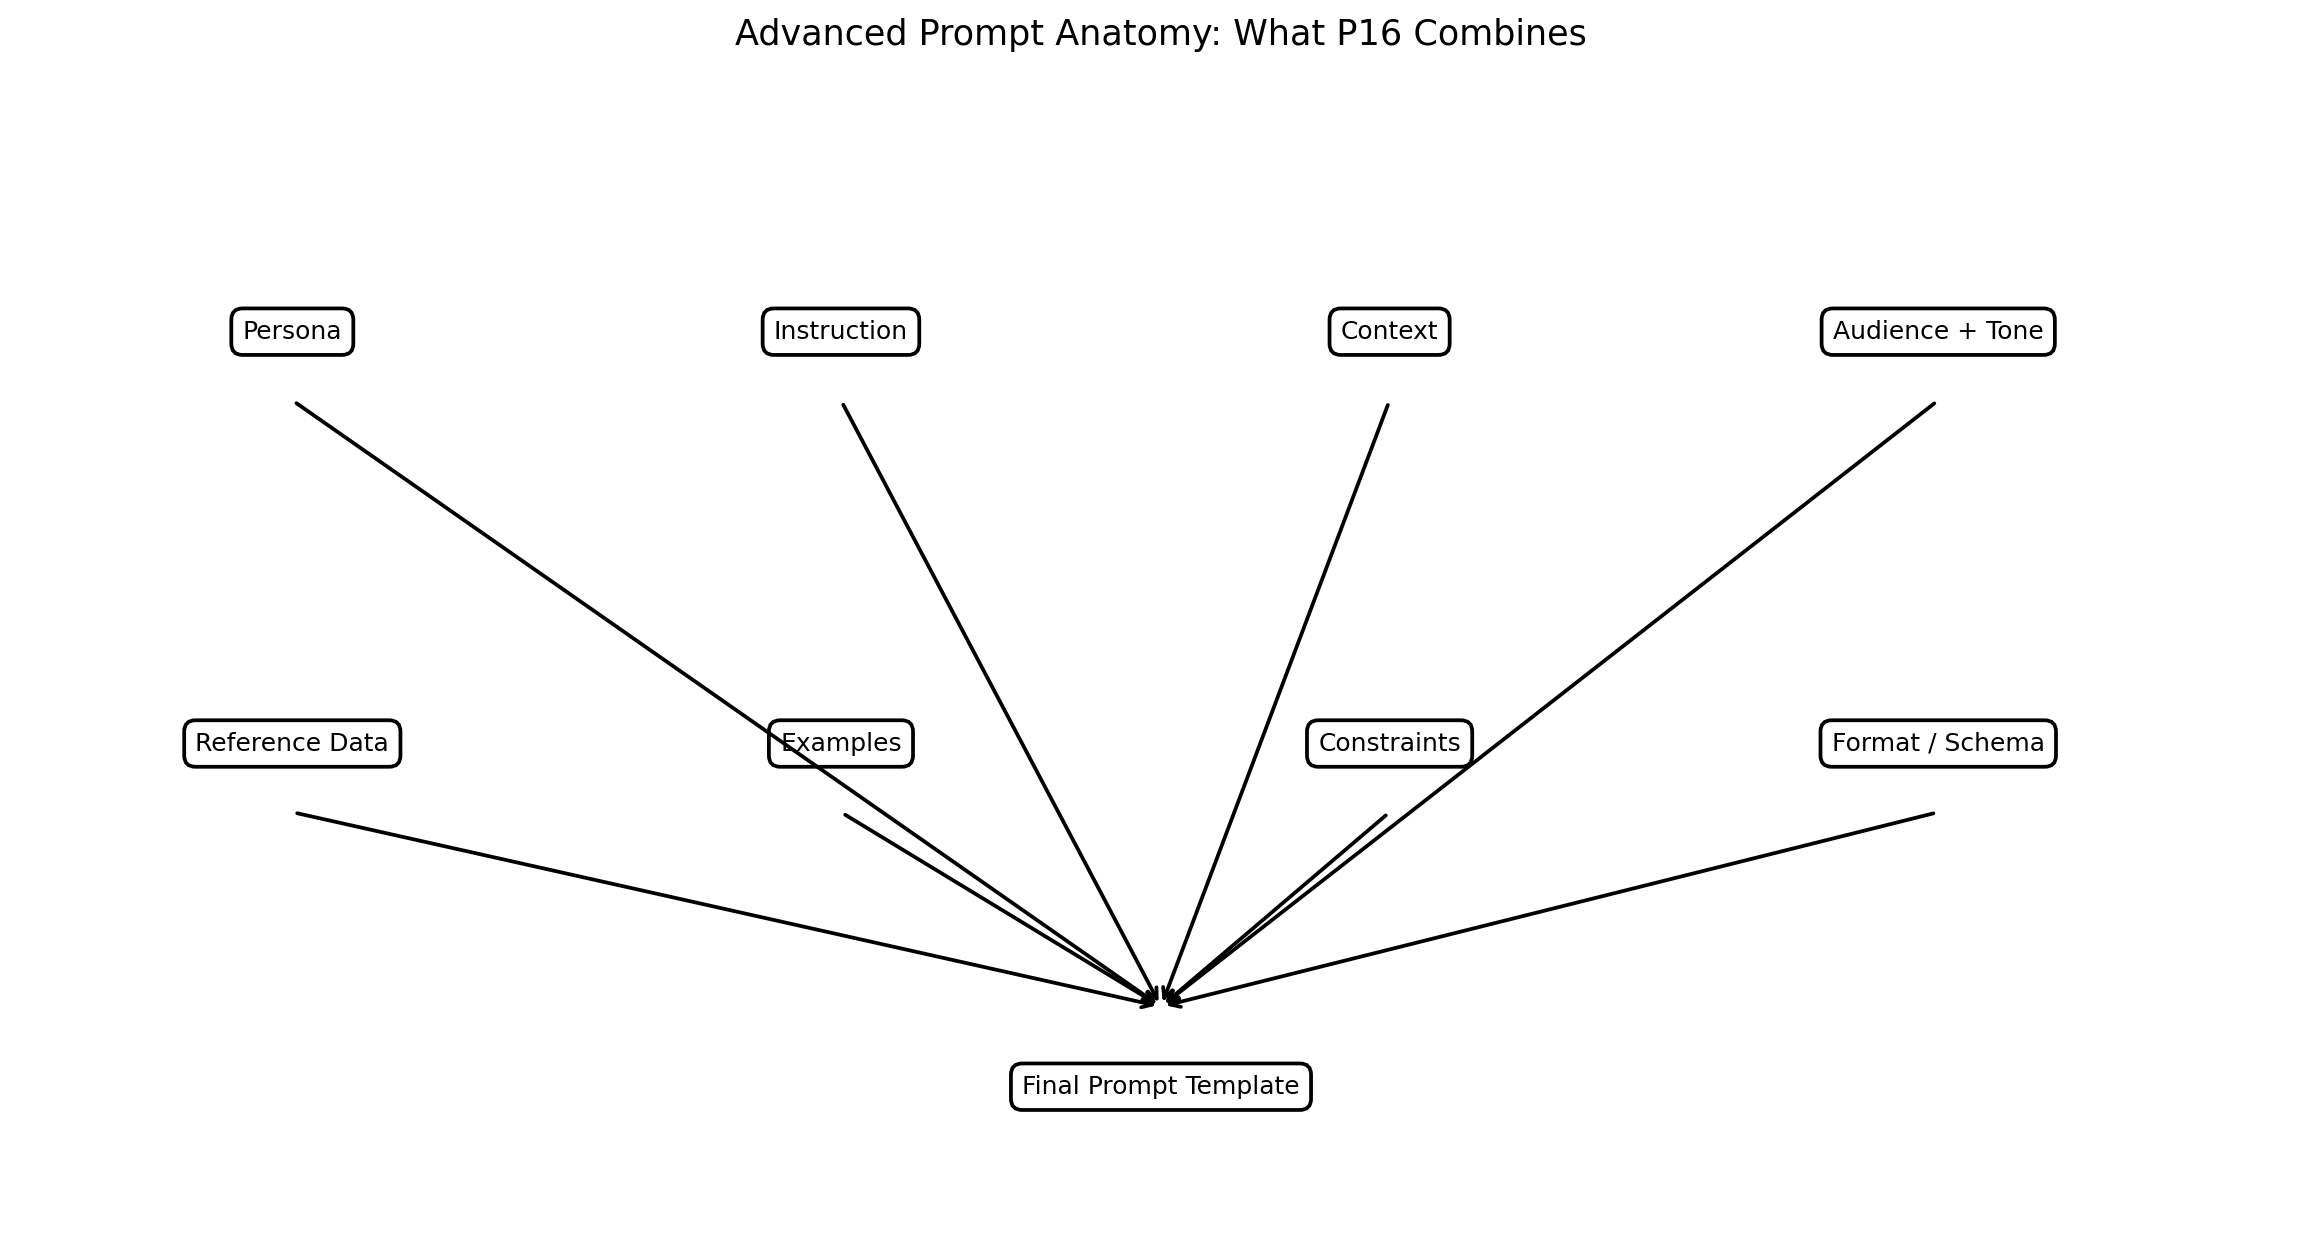

In [2]:
from IPython.display import Image, display
path = PROJECT_ROOT / "07_outputs/reports/figures/00f_advanced_prompt_anatomy.png"
if path.exists(): display(Image(filename=str(path)))

## 2. P0–P16 technique catalog
Nem minden technika „jobb”. Például a persona önmagában lehet, hogy semmit sem ad egy egyszerű klasszifikációhoz, miközben tokeneket fogyaszt. Ezt pont a benchmarknak kell megmutatnia.

In [3]:
from prompt_benchmark.prompts import TECHNIQUE_CATALOG, list_strategies
catalog = pd.DataFrame([{"strategy": k, **v} for k,v in TECHNIQUE_CATALOG.items()])
catalog

,strategy,title,category,hypothesis
0,p0_zero_shot,Zero-shot baseline,Core,Minimal instruction establishes the baseline.
1,p1_definitions,Label definitions,Context,Explicit label semantics reduce class ambiguity.
2,p2_role,Role / system prompt,Persona,System-level role improves instruction adherence.
3,p3_few_shot,Few-shot examples,Examples,Demonstrations teach the desired input-to-labe...
4,p4_constraints,Explicit constraints,Instruction,Negative and positive constraints reduce inval...
5,p5_decision_policy,Structured decision policy,Reasoning policy,A deterministic policy helps resolve overlappi...
6,p6_json,Prompt-only JSON,Format,Explicit JSON instructions improve machine-rea...
7,p7_structured_output,Schema structured output,Format,Provider-enforced schema reduces formatting fa...
8,p8_persona,Domain persona,Persona,A specialized persona may improve domain-sensi...
9,p9_instruction_context,Instruction + context blocks,Prompt anatomy,Sectioned instructions reduce ambiguity betwee...


## 3. Prompt preview és prompt overhead
Ugyanarra a ticketre rendereljük az összes stratégiát. A prompt karakter-/szóhossza nem quality metric, de jó proxy a context overheadhez.

In [4]:
from prompt_benchmark.prompts import get_strategy
sample = "Please cancel my subscription; I was also charged today."
rows=[]
for name in list_strategies():
    strategy=get_strategy(name)
    payload=strategy.build(sample)
    text=(payload.instructions or "")+"\n"+payload.input_text
    rows.append({
        "strategy":name,
        "title":TECHNIQUE_CATALOG[name]["title"],
        "characters":len(text),
        "approx_tokens":round(len(text)/4),
        "structured_output":payload.structured_output,
        "reasoning_effort":payload.reasoning_effort,
    })
prompt_complexity=pd.DataFrame(rows)
prompt_complexity

,strategy,title,characters,approx_tokens,structured_output,reasoning_effort
0,p0_zero_shot,Zero-shot baseline,203,51,False,None
1,p1_definitions,Label definitions,770,192,False,None
2,p2_role,Role / system prompt,773,193,False,None
3,p3_few_shot,Few-shot examples,775,194,False,None
4,p4_constraints,Explicit constraints,1039,260,False,None
5,p5_decision_policy,Structured decision policy,1506,376,False,None
6,p6_json,Prompt-only JSON,1575,394,False,None
7,p7_structured_output,Schema structured output,1431,358,True,None
8,p8_persona,Domain persona,893,223,False,None
9,p9_instruction_context,Instruction + context blocks,1288,322,False,None


### Döntés
A hosszabb promptot csak akkor tartjuk meg, ha a Macro F1 / output validity javulása indokolja a plusz token- és latency-költséget.

## 4. Tree-of-Thought-inspired branch + vote
Itt nem kérünk hidden chain-of-thoughtot. Három külön expert branch ugyanazt a ticketet osztályozza, csak **final labelt** ad, majd majority vote történik.

In [5]:
tree = get_strategy("p14_tree_branch_vote")
for idx,payload in enumerate(tree.build_branches(sample),1):
    print(f"\n--- BRANCH {idx} ---")
    print(payload.instructions)
    print(payload.input_text[-350:])


--- BRANCH 1 ---
You are a lexical intent specialist. Focus on explicit user action and keywords.
ilure -> technical.
5. Plan/tier/capacity change -> upgrade.
6. Otherwise, general dissatisfaction/escalation -> complaint.
Return only the final classification; do not reveal hidden reasoning.

Message: Please cancel my subscription; I was also charged today.
Return exactly one label from: api, billing, cancellation, complaint, technical, upgrade.

--- BRANCH 2 ---
You are a policy specialist. Apply category definitions and precedence rules strictly.
ilure -> technical.
5. Plan/tier/capacity change -> upgrade.
6. Otherwise, general dissatisfaction/escalation -> complaint.
Return only the final classification; do not reveal hidden reasoning.

Message: Please cancel my subscription; I was also charged today.
Return exactly one label from: api, billing, cancellation, complaint, technical, upgrade.

--- BRANCH 3 ---
You are an ambiguity specialist. Resolve multi-intent and near-boundary tick

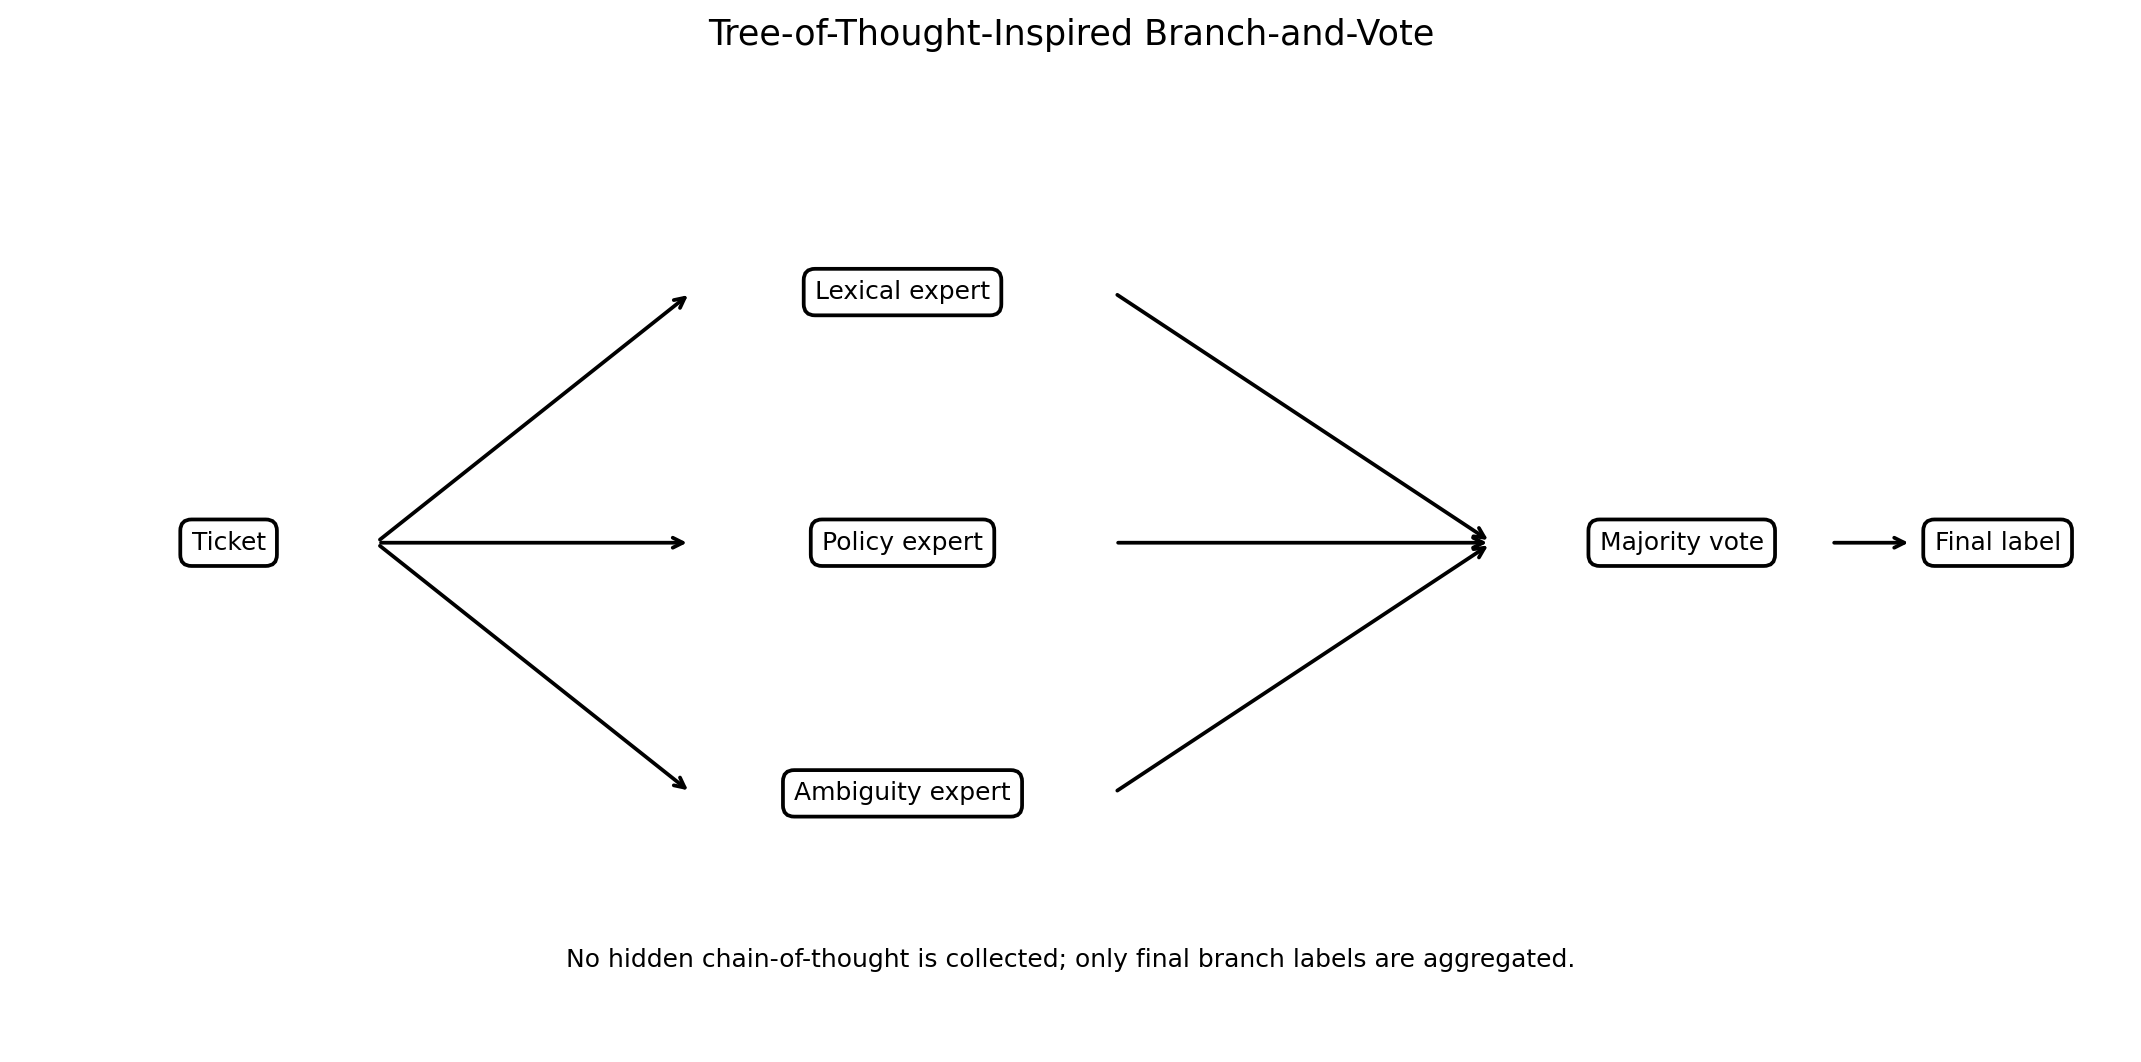

In [6]:
path = PROJECT_ROOT / "07_outputs/reports/figures/00h_tree_branch_vote.png"
if path.exists(): display(Image(filename=str(path)))

## 5. Valódi benchmark eredmények
Ha már futott `generate_report.py`, itt összevetjük a technikákat. Mock provider esetén ezek csak pipeline-demó eredmények.

In [7]:
summary_path=PROJECT_ROOT/"07_outputs/results/mock/benchmark_summary.csv"
if summary_path.exists():
    summary=pd.read_csv(summary_path)
    display(summary[["strategy","macro_f1","output_contract_valid_rate","mean_total_tokens","p95_latency_seconds"]].sort_values("macro_f1",ascending=False))
else:
    print("Run the benchmark/report first.")

,strategy,macro_f1,output_contract_valid_rate,mean_total_tokens,p95_latency_seconds
0,p14_tree_branch_vote,0.946599,1.000000,1391.506667,1.590605
1,p16_full_advanced_template,0.917515,1.000000,1607.210000,1.082600
2,p13_reasoning_model,0.894515,1.000000,489.903333,0.820710
3,p5_decision_policy,0.844015,0.986667,1333.830000,0.887315
4,p15_grammar_constrained,0.834862,1.000000,325.886667,0.493810
5,p7_structured_output,0.826353,1.000000,1325.580000,0.902725
6,p6_json,0.821044,0.970000,1371.563333,0.894540
7,p12_contrastive_few_shot,0.818540,0.993333,1317.186667,0.895960
8,p11_delimited_data,0.814141,0.996667,348.233333,0.440805
9,p4_constraints,0.808881,0.986667,1199.526667,0.797800


## 6. Interjúban hogyan magyarázd?
Ne azt mondd, hogy „kipróbáltam 17 promptot”. Mondd el, hogy **kontrollált interventionöket** építettél, megtartottad a model/dataset/evaluation kontrollváltozókat, majd quality–reliability–cost alapján választottál.